<a href="https://colab.research.google.com/github/agcp-cesar/ciencia-de-dados/blob/main/Projeto_1_Luciano_(Ci%C3%AAncia_de_Dados).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fonte carregada: https://raw.githubusercontent.com/ryanleeallred/datasets/master/kc_house_data.csv
Shape inicial: (21613, 21)

--- Valores ausentes ---
preco        0
area_ft2     0
area_m2      0
quartos      0
banheiros    0
bairro       0
preco_m2     0
dtype: int64
Shape após limpeza: (20905, 7)

--- Estatísticas descritivas ---
              preco       area_m2   quartos     banheiros      preco_m2
count  2.090500e+04  20905.000000   20905.0  20905.000000  20905.000000
mean   5.162368e+05    193.384787  3.386415      2.120557   2718.300822
std    2.996953e+05     82.833710  0.919672      0.754074    977.321151
min    7.500000e+04     26.941870       0.0      0.000000    942.792324
25%    3.190000e+05    133.780320       3.0      1.750000   1941.418860
50%    4.450000e+05    178.373760       3.0      2.250000   2589.984004
75%    6.270000e+05    236.345232       4.0      2.500000   3321.676910
max    4.668000e+06   1257.906620      33.0      8.000000   5621.917415


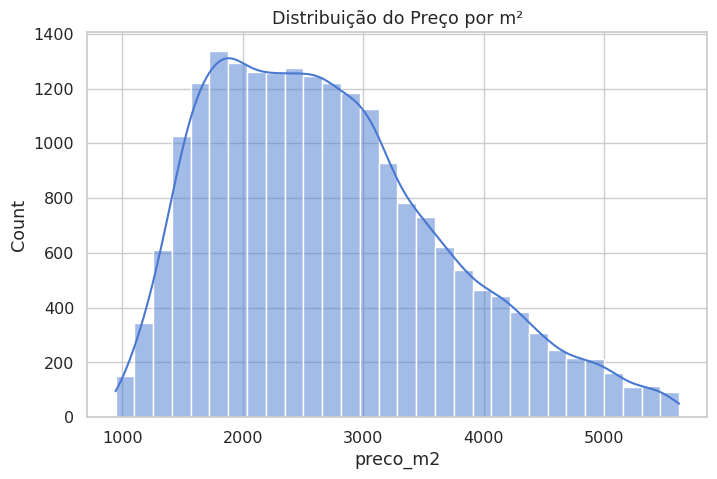

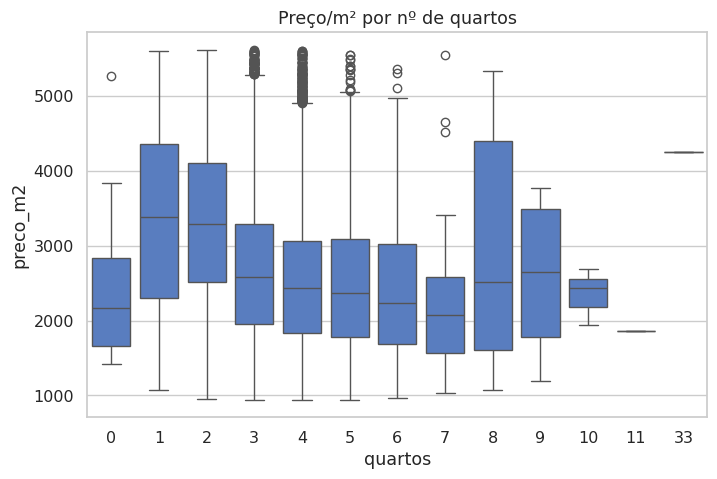

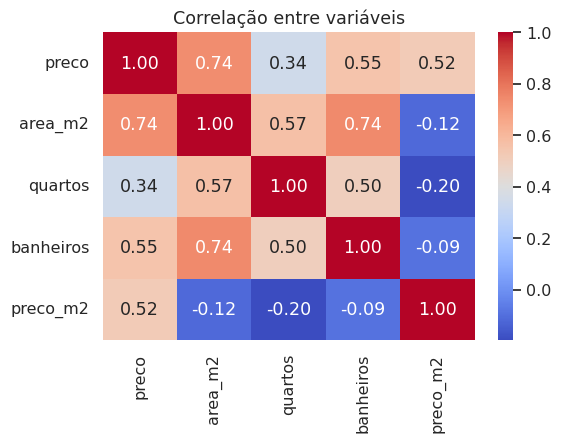


--- Teste de hipóteses ---
Bairros comparados: 98038 (n=590) vs 98052 (n=570)
t-test: t=-41.672, p=0.000000
Mann-Whitney: U=13070, p=0.000000


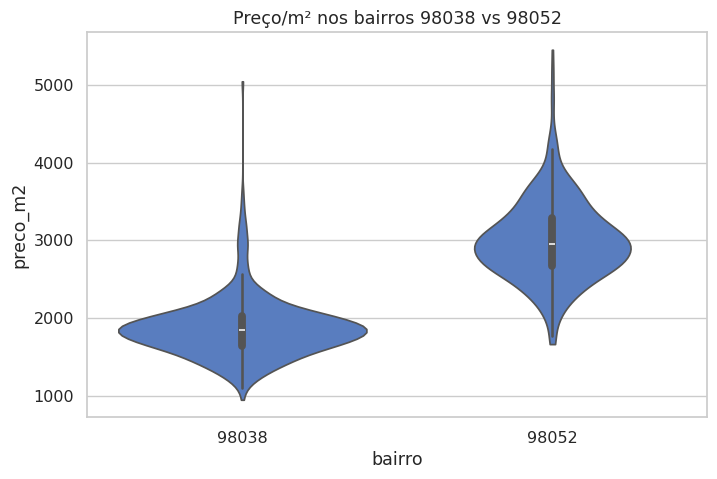


--- Bônus: Ajuste de preços pelo IPCA ---
Inflação acumulada (12 meses): -0.11%
      preco_m2  preco_m2_corrigido
0  2024.163347         2021.936768
1  2253.302061         2250.823429
2  2516.239882         2513.472018
3  3317.043210         3313.394462
4  3267.617069         3264.022690


In [ ]:
# PROJETO 1 - Ciência de Dados
# Alunos: Bruno Souza e André Poroca

# 1) Bibliotecas e setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy import stats
import requests, warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
sns.set(style="whitegrid", palette="muted", font_scale=1.05)
np.random.seed(42)

# 2) Coleta de dados (com fallback)
#    Dataset: KC House Sales (Seattle)
urls = [
    "https://raw.githubusercontent.com/harlfoxem/housesalesprediction/master/kc_house_data.csv",
    "https://raw.githubusercontent.com/ryanleeallred/datasets/master/kc_house_data.csv"
]

df = None
err = None
for u in urls:
    try:
        df = pd.read_csv(u)
        fonte_usada = u
        break
    except Exception as e:
        err = e
        continue

if df is None:
    raise RuntimeError(f"Falha ao baixar o dataset. Último erro: {err}")

print("Fonte carregada:", fonte_usada)
print("Shape inicial:", df.shape)
df.head()

# 3) Pré-processamento

# Renomear colunas
FT2_TO_M2 = 0.092903
df = df.rename(columns={
    "price": "preco",
    "sqft_living": "area_ft2",
    "bedrooms": "quartos",
    "bathrooms": "banheiros",
    "zipcode": "bairro"   # usando o CEP como proxy de bairro
})

# Criar coluna de área em m² e preço/m²
df["area_m2"] = df["area_ft2"] * FT2_TO_M2
df["preco_m2"] = df["preco"] / df["area_m2"]

# Selecionar colunas úteis
df = df[["preco", "area_ft2", "area_m2", "quartos", "banheiros", "bairro", "preco_m2"]]

# Tipagem
df["quartos"]   = df["quartos"].astype("Int64")
df["banheiros"] = pd.to_numeric(df["banheiros"], errors="coerce")
df["bairro"]    = df["bairro"].astype(str)

# Tratar ausentes
print("\n--- Valores ausentes ---")
print(df.isna().sum())
df = df.dropna()

# Limpeza univariada (outliers em preco_m2 via IQR)
Q1, Q3 = df["preco_m2"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
df = df[df["preco_m2"].between(lower, upper)]

# Filtrar registros inválidos
df = df[df["area_m2"] > 10]
df = df[(df["quartos"] >= 0) & (df["banheiros"] >= 0)]

print("Shape após limpeza:", df.shape)

# Normalização (preco_m2)
scaler = StandardScaler()
df["preco_m2_norm"] = scaler.fit_transform(df[["preco_m2"]])

# Discretização (quartis de preço/m²)
df["faixa_preco"] = pd.qcut(df["preco_m2"], q=4,
                            labels=["baixo", "médio-baixo", "médio-alto", "alto"])

df.head()


# 4) Estatísticas descritivas + visualizações

print("\n--- Estatísticas descritivas ---")
print(df[["preco", "area_m2", "quartos", "banheiros", "preco_m2"]].describe())

# Histograma
plt.figure(figsize=(8,5))
sns.histplot(df["preco_m2"], bins=30, kde=True)
plt.title("Distribuição do Preço por m²")
plt.show()

# Boxplot por nº de quartos
plt.figure(figsize=(8,5))
sns.boxplot(x="quartos", y="preco_m2", data=df)
plt.title("Preço/m² por nº de quartos")
plt.show()

# Heatmap de correlação
plt.figure(figsize=(6,4))
sns.heatmap(df[["preco","area_m2","quartos","banheiros","preco_m2"]].corr(),
            annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlação entre variáveis")
plt.show()

# -----------------------------
# 5) Teste de hipóteses
# -----------------------------
# Comparar preço/m² em dois bairros (os mais frequentes com >=100 amostras)
top_bairros = df["bairro"].value_counts().loc[lambda s: s>=100].head(2).index.tolist()
if len(top_bairros) < 2:
    top_bairros = df["bairro"].value_counts().head(2).index.tolist()

b1, b2 = top_bairros
g1 = df.loc[df["bairro"]==b1, "preco_m2"]
g2 = df.loc[df["bairro"]==b2, "preco_m2"]

t, p = stats.ttest_ind(g1, g2, equal_var=False)
u, p_u = stats.mannwhitneyu(g1, g2, alternative="two-sided")

print("\n--- Teste de hipóteses ---")
print(f"Bairros comparados: {b1} (n={len(g1)}) vs {b2} (n={len(g2)})")
print(f"t-test: t={t:.3f}, p={p:.6f}")
print(f"Mann-Whitney: U={u:.0f}, p={p_u:.6f}")

# Visual
plt.figure(figsize=(8,5))
sns.violinplot(data=df[df["bairro"].isin([b1, b2])], x="bairro", y="preco_m2", cut=0)
plt.title(f"Preço/m² nos bairros {b1} vs {b2}")
plt.show()

# -----------------------------
# 6) Bônus – Integração Web
# -----------------------------
print("\n--- Bônus: Ajuste de preços pelo IPCA ---")
try:
    url_bc = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.433/dados/ultimos/12?formato=json"
    resp = requests.get(url_bc, timeout=20)
    resp.raise_for_status()
    series = resp.json()
    ipca_12m = float(series[-1]["valor"])
    print(f"Inflação acumulada (12 meses): {ipca_12m:.2f}%")

    df["preco_m2_corrigido"] = df["preco_m2"] * (1 + ipca_12m/100)
    print(df[["preco_m2", "preco_m2_corrigido"]].head())
except Exception as e:
    print("Erro ao consultar IPCA:", e)
